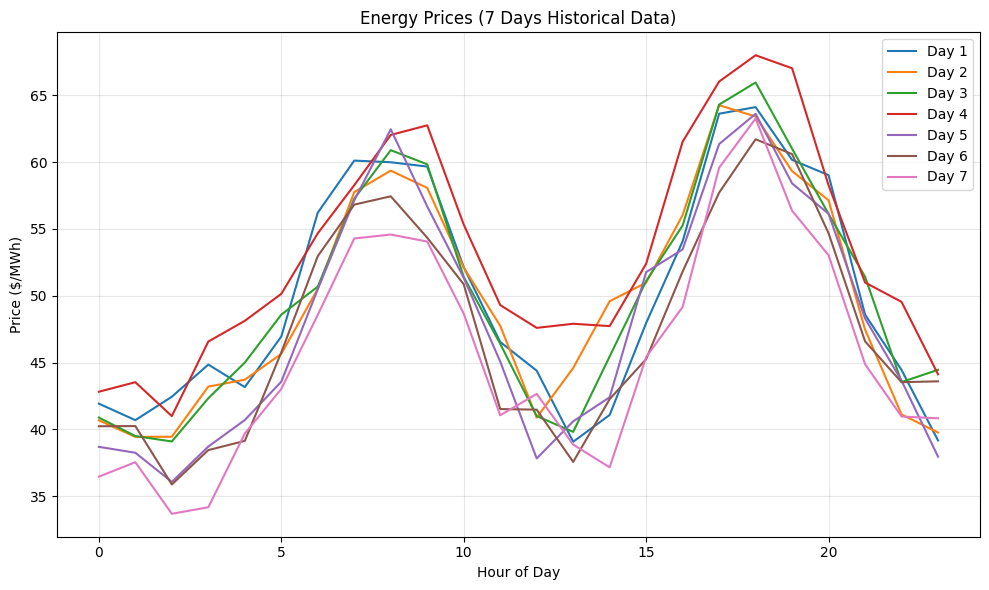

In [27]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

hours = np.arange(0, 24)
days = 7

plt.figure(figsize=(10, 6))

def generate_price(hours, shift=None):
    """Generate realistic double-peak daily energy price pattern."""
    morning_peak = np.exp(-0.5 * ((hours - 8) / 2)**2) * 20
    evening_peak = np.exp(-0.5 * ((hours - 18) / 2)**2) * 25
    base_price = 40 + morning_peak + evening_peak
    noise = np.random.normal(0, 2, size=hours.shape)
    daily_shift = np.random.uniform(-5, 5) if shift is None else shift
    return base_price + daily_shift + noise

for day in range(days):
    prices = generate_price(hours)
    plt.plot(hours, prices, label=f'Day {day + 1}')

plt.title('Energy Prices (7 Days Historical Data)')
plt.xlabel('Hour of Day')
plt.ylabel('Price ($/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


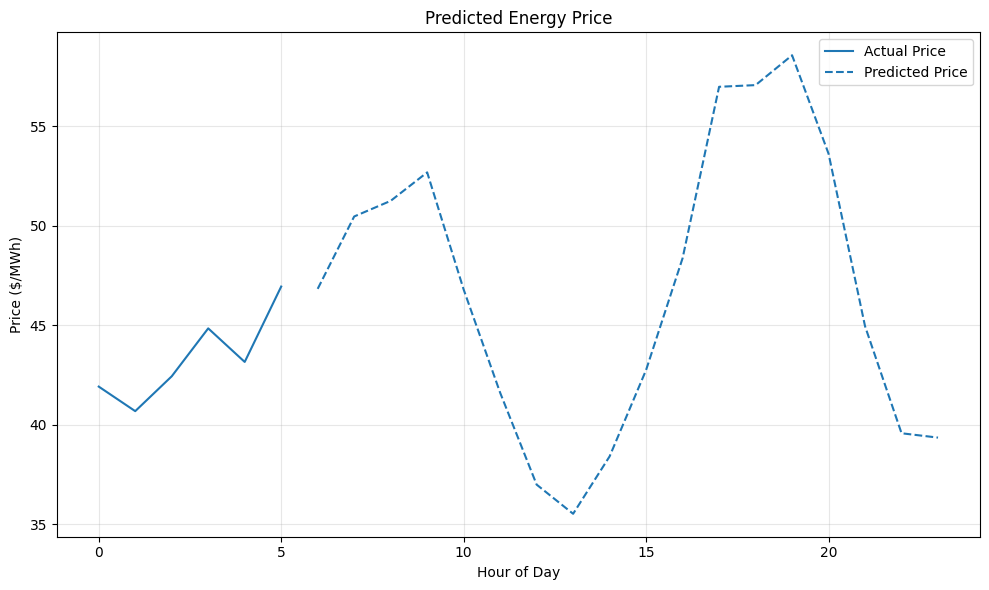

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

hours = np.arange(0, 24)

def generate_price(hours, shift=None):
    """Same function as used in 7-day version."""
    morning_peak = np.exp(-0.5 * ((hours - 8) / 2)**2) * 20
    evening_peak = np.exp(-0.5 * ((hours - 18) / 2)**2) * 25
    base_price = 40 + morning_peak + evening_peak
    noise = np.random.normal(0, 2, size=hours.shape)
    daily_shift = np.random.uniform(-5, 5) if shift is None else shift
    return base_price + daily_shift + noise

# Generate the current day's prices (same pattern logic)
prices = generate_price(hours)

# Split 25% actual, 75% predicted (no gap)
split_point = int(0.25 * len(hours))
hours_actual = hours[:split_point]
hours_pred = hours[split_point:]
prices_actual = prices[:split_point]

# Predicted continuation uses same shape trend + slight uncertainty
last_val = prices_actual[-1]
remaining_base = generate_price(hours_pred)  # same model for continuation
trend_adjustment = (remaining_base - remaining_base[0]) * 0.9  # smoother continuation
prices_pred = last_val + trend_adjustment + np.random.normal(0, 1, len(hours_pred))

plt.figure(figsize=(10, 6))
plt.plot(hours_actual, prices_actual, color='tab:blue', label='Actual Price')
plt.plot(hours_pred, prices_pred, color='tab:blue', linestyle='--', label='Predicted Price')

plt.title('Predicted Energy Price')
plt.xlabel('Hour of Day')
plt.ylabel('Price ($/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


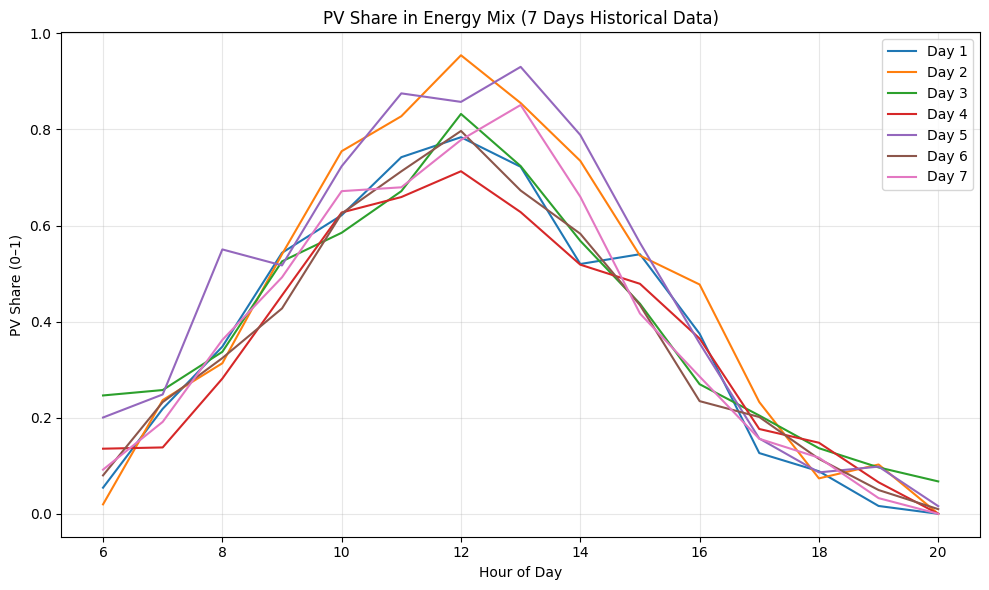

In [29]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

hours = np.arange(6, 21)  # 6:00 to 20:00
days = 7

plt.figure(figsize=(10, 6))

for day in range(days):
    # Base PV share: low morning, peak midday, fall evening
    base_pv = np.exp(-0.5 * ((hours - 12)/3)**2)  # Gaussian peak at noon
    base_pv = base_pv / np.max(base_pv)  # normalize to 0–1
    
    # Add variability for cloudiness
    cloud_factor = np.random.uniform(0.7, 1.0)  # partially cloudy to sunny
    pv_share = base_pv * cloud_factor + np.random.normal(0, 0.05, size=hours.shape)
    pv_share = np.clip(pv_share, 0, 1)  # keep in 0–1
    
    plt.plot(hours, pv_share, label=f'Day {day+1}')

plt.title('PV Share in Energy Mix (7 Days Historical Data)')
plt.xlabel('Hour of Day')
plt.ylabel('PV Share (0–1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


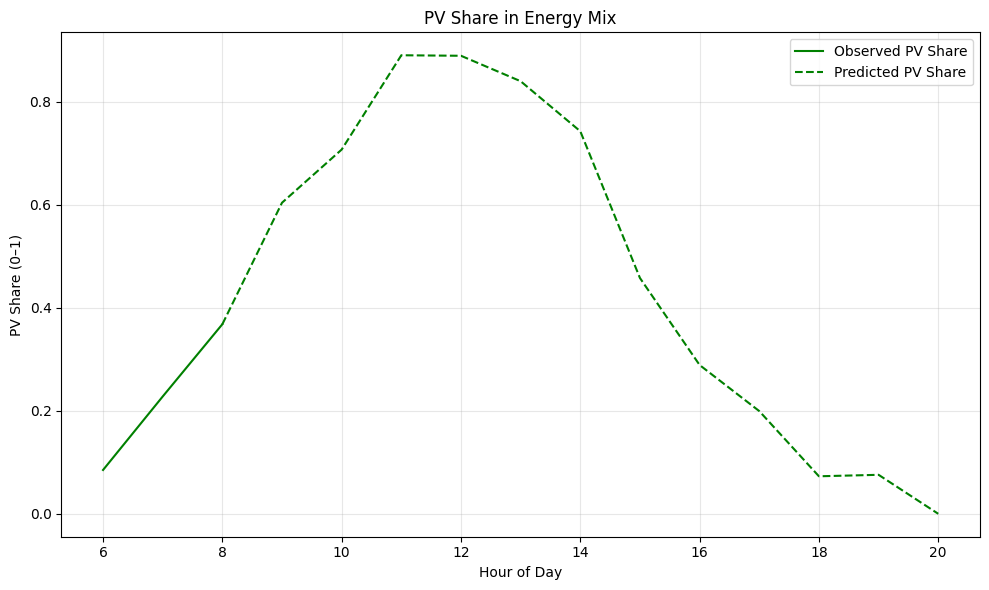

Volatility Energy Ratio (VER): 0.728


In [30]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

hours = np.arange(6, 21)
split_idx = int(0.25 * len(hours))  # first 25% actual

# Base PV share pattern
base_pv = np.exp(-0.5 * ((hours - 12)/3)**2)
base_pv = base_pv / np.max(base_pv)

# Actual PV share (first 25%)
cloud_factor_actual = np.random.uniform(0.8, 1.0)
pv_actual = base_pv[:split_idx] * cloud_factor_actual + np.random.normal(0, 0.03, split_idx)
pv_actual = np.clip(pv_actual, 0, 1)

# Predicted PV share (remaining 75%)
cloud_factor_pred = np.random.uniform(0.7, 1.0)
pv_pred = base_pv[split_idx:] * cloud_factor_pred + np.random.normal(0, 0.05, len(hours) - split_idx)
pv_pred = np.clip(pv_pred, 0, 1)

# Combine for smooth plotting
pv_all = np.concatenate((pv_actual, pv_pred))

plt.figure(figsize=(10, 6))
plt.plot(hours[:split_idx], pv_actual, 'g-', label='Observed PV Share')
plt.plot(hours[split_idx-1:], pv_all[split_idx-1:], 'g--', label='Predicted PV Share')

plt.title('PV Share in Energy Mix')
plt.xlabel('Hour of Day')
plt.ylabel('PV Share (0–1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Volatility Energy Ratio (VER) = std/mean
ver = np.std(pv_all) / np.mean(pv_all)
print(f"Volatility Energy Ratio (VER): {ver:.3f}")


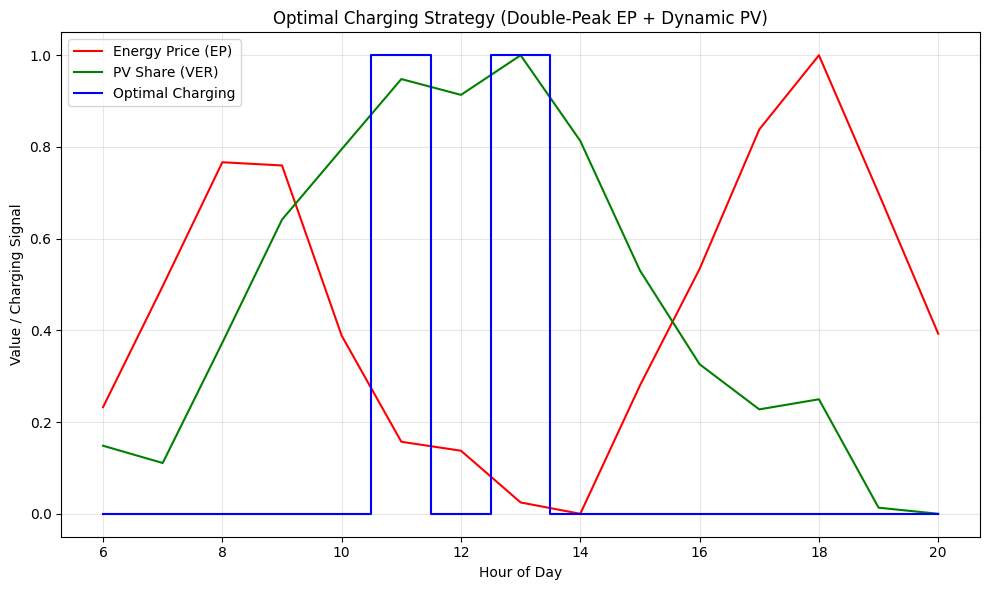

Binary Charging Signal: [0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [54]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
hours = np.arange(6, 21)  # 6:00 to 20:00

# -----------------------------
# Energy Price (EP) - double peak + fluctuations
# -----------------------------
morning_peak = 20 * np.exp(-0.5 * ((hours - 8)/1.5)**2)
evening_peak = 25 * np.exp(-0.5 * ((hours - 18)/2)**2)
base_price = 50 + morning_peak + evening_peak

# Add dynamic fluctuations
fluctuation = 3 * np.sin(0.8 * hours) + np.random.normal(0, 2, size=hours.shape)
ep = base_price + fluctuation
ep = (ep - np.min(ep)) / (np.max(ep) - np.min(ep))  # normalize 0-1

# -----------------------------
# PV Share (VER) - more dynamic
# -----------------------------
ver = np.exp(-0.5 * ((hours - 12)/3)**2)
ver = ver + 0.1 * np.sin(1.5 * hours) + np.random.normal(0, 0.05, size=hours.shape)
ver = np.clip(ver, 0, 1)

# -----------------------------
# Optimal Charging Strategy
# -----------------------------
ep_threshold = 0.2
ver_threshold = 0.94
charge = np.where((ep < ep_threshold) & (ver > ver_threshold), 1, 0)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(hours, ep, 'r-', label='Energy Price (EP)')
plt.plot(hours, ver, 'g-', label='PV Share (VER)')
plt.step(hours, charge, 'b-', where='mid', label='Optimal Charging')
plt.title('Optimal Charging Strategy (Double-Peak EP + Dynamic PV)')
plt.xlabel('Hour of Day')
plt.ylabel('Value / Charging Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Binary Charging Signal:", charge)
